<a href="https://colab.research.google.com/github/Aneesh712/hds5210-2023/blob/main/final/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project

**Unveiling Life Expectancy Patterns in U.S. States for Informed Health Strategies**

**Project Outline:**
By examining the nuances of state-level data from the United States, my investigation reveals complex trends in life expectancy and demographics. my thorough research, which is illustrated with striking visualisations, makes use of the Snowflake and JSON datasets to highlight differences and concentrations. This trip highlights the critical role that data-driven decision-making plays in the public policy and healthcare domains, providing useful information for well-informed initiatives and enhanced public health outcomes.

In [56]:
!pip install "snowflake-connector-python[pandas]"

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import snowflake.connector

The code starts by importing necessary libraries, including pandas for data manipulation, numpy for numerical operations, seaborn for statistical visualization, matplotlib for plotting, and snowflake.connector for connecting to a Snowflake database.

## **Statistical Exploration Tools:**

In [58]:
# Class for Data Analysis
class DataAnalyzing:

    def __init__(self, data):
        self.data = data

    def check_null_values(self):
        print("Checking for Null Values\n")
        for col, count in self.data.isna().sum().sort_values(ascending=False).to_dict().items():
            if count > 0:
                print(f"{col}: {count} missing values")

    def check_duplicates(self):
        print("\nChecking for Duplicates:", self.data.duplicated().sum())

    def describe_data(self):
        print("\nDescriptive Statistics for Numeric Columns:")
        display(self.data.describe())

    @staticmethod
    def drop_data(data_frame):
        data_frame = data_frame.dropna(axis=0)
        data_frame = data_frame.drop_duplicates()
        return data_frame

    @staticmethod
    def update_data(target_value, new_value, data_frame):
        for col in data_frame.columns:
            data_frame.loc[data_frame[data_frame[col] == target_value].index, [col]] = new_value
        return data_frame

    @staticmethod
    def bar_plot(data1, title, x, y, hue, figsize=(15, 6)):
        plt.title(title)
        sns.barplot(data=data1, x=x, y=y, hue=hue)
        plt.show()

Explanation:

The DataAnalyzing class is a versatile tool designed for thorough data analysis. It provides essential functions for handling null values, detecting duplicates, generating descriptive statistics, and facilitating data cleaning. The class includes methods for removing null values and duplicates, updating data based on specified criteria, and creating bar plots for easy visualization of relationships between variables. This comprehensive class streamlines the exploratory phase of data analysis, offering key functionalities to enhance data understanding and quality assessment.







## **Data 1: Snowflake Connection and CSV Dive:**

In [59]:
# Function to connect to Snowflake and fetch data
def fetch_snowflake_data(User,password,account, database):
    con = snowflake.connector.connect(
        user=User,
        password=password,
        account=account,
        database=database,
        schema='PUBLIC',
        warehouse='COMPUTE_WH',
        session_parameters={
            'QUERY_TAG': 'Demo User Interaction',
        }
    )
    cursor = con.cursor()
    query = '''SELECT * FROM IDENTIFIER('"NEWDATA"."PUBLIC"."US_STATE"');'''
    snowflake_data = cursor.execute(query).fetch_pandas_all()
    return snowflake_data

**Gruoupby Function**

The groupby_fun function takes a DataFrame (data) and a specified column (col) as input, grouping the DataFrame based on the unique values in the specified column. It then counts the non-null occurrences for each column within each group and returns a new DataFrame representing the counts for each unique value in the specified column. This function is a straightforward utility for obtaining a quick overview of the distribution of data across different categories or values in a DataFrame column, providing a concise summary of counts for each group.

In [60]:
def groupby_fun(data,col):
    gp1 = data.groupby(col).count()

    return gp1

# **Data 2: JSON Exploration and Cleanup**

**Data 2: JSON Exploration and Cleanup**


The function, titled "Data 2: JSON Exploration and Cleanup," reads a JSON file specified by file_path into a pandas DataFrame (d2). It then utilizes the DataAnalyzing class to replace newline characters with NaN values, providing a clean and processed DataFrame. The function returns the cleaned DataFrame, encapsulating the exploration and preprocessing steps for JSON data.

In [61]:

def explore_cleanup_json(file_path):
    d2 = pd.read_json(file_path)
    obj3 = DataAnalyzing(d2)
    d2 = obj3.update_data("\n", np.nan, d2)
    return d2

**Merging Data Horizons: Correlations Revealed**

The function, titled "Merging Data Horizons: Correlations Revealed," merges two DataFrames (data1 and data2) using the join method, creating a new DataFrame (j1). This function facilitates the combination of information from different datasets, uncovering potential correlations and relationships between variables in the merged data.

In [62]:
# Merging Data Horizons: Correlations Revealed
def merge_data(data1, data2):
    j1 = data1.join(data2)
    return j1

**Pharmaceutical EDA: Visualizing Insights**


The function, titled "Pharmaceutical EDA: Visualizing Insights," generates a specific type of visualization for exploratory data analysis (EDA). It utilizes the seaborn and matplotlib libraries to create a bar plot based on the provided parameters: DataFrame (data), x-axis (x), y-axis (y), hue (color-coding) (hue), and the title of the plot (title). This function is designed to visually convey insights related to drug types and their effectiveness, offering a clear and informative representation of pharmaceutical data trends.

In [63]:
# Pharmaceutical EDA: Visualizing Insights
def visualize_insights(data,x,y,hue,title):
    plt.figure(figsize=(13, 12))
    # Graph 2: Drug Type vs. Effectiveness
    sns.barplot(data=data, x=x, y=y, hue=hue)
    plt.title(title)
    plt.show()

## **MAIN FUNCTION**


The main function serves as the central orchestrator of the entire project. It starts by loading data from two different sources: Snowflake and a JSON file. The Snowflake data is displayed and then undergoes transformation using the groupby_fun function, grouping the data by the "STATE" column and displaying the count of rows for each group.

The JSON data is loaded from the specified file path and cleaned using the explore_cleanup_json function. The cleaned JSON data is displayed, and a separate grouping operation is performed based on the 'County' column.

After the individual transformations, the function proceeds to merge the two datasets using the merge_data function, resulting in a combined dataset (merged_data). The shape of the merged data is printed, and the merged data is displayed.

The final output of the function includes the original Snowflake data, the cleaned JSON data, and the merged dataset. The main function acts as a comprehensive driver, showcasing various data loading, cleaning, transformation, and merging processes in the project.

In [64]:
def main():
    # Load data from Snowflake
    snowflake_data = fetch_snowflake_data("aneeshreddy","Aneesh@1999","lxwydpo-bg68517","NEWDATA" )
    display(snowflake_data)

    # Load data from JSON file
    json_file_path = r'/content/U.S._Life_Expectancy_at_Birth_by_State_and_Census_Tract_-_2010-2015 (1).json'
    json_data = explore_cleanup_json(json_file_path)
    display(json_data)

    # Data 1 Transformation
    transformed_data1 = groupby_fun(snowflake_data,"STATE")
    display(transformed_data1.count())
    # Merging Data

    # Data 2 Transformation
    grouped_data = json_data.groupby('County')

    # Display the count of rows for each group
    display(grouped_data.size())
    # Merging Data

    merged_data = merge_data(transformed_data1, json_data)
    print("shape :",merged_data.shape)
    display(merge_data)


    return snowflake_data,json_data,merged_data


**MEREGE**

In [65]:
snowflake_data,json_data,merged_data = main()

,STATE,SEX,LE,SE,QUARTILE
0,Alabama,Total,73,0.0,71.9 - 75.3
1,Alaska,Total,77,0.0,75.4 - 76.8
2,Arizona,Total,76,0.0,75.4 - 76.8
3,Arkansas,Total,74,0.0,71.9 - 75.3
4,California,Total,79,0.0,78.1 - 80.7
...,...,...,...,...,...
151,Virginia,Female,80,0.0,79.7 - 80.7
152,Washington,Female,82,0.0,80.0 - 83.8
153,West Virginia,Female,76,0.0,75.2 - 78.2
154,Wisconsin,Female,80,0.0,79.7 - 80.7


,ï»¿State,County,Census Tract Number,Life Expectancy,Life Expectancy Range,Life Expectancy Standard Error
0,Alabama,(blank),,75.5,75.2-77.5,0.0328
1,Alabama,"Autauga County, AL",0201.00,73.1,56.9-75.1,2.2348
2,Alabama,"Autauga County, AL",0202.00,76.9,75.2-77.5,3.3453
3,Alabama,"Autauga County, AL",0203.00,,,
4,Alabama,"Autauga County, AL",0204.00,75.4,75.2-77.5,1.0216
...,...,...,...,...,...,...
73116,Wyoming,"Washakie County, WY",0002.00,80.1,79.6-81.6,2.6916
73117,Wyoming,"Washakie County, WY",0003.01,79.9,79.6-81.6,2.8024
73118,Wyoming,"Washakie County, WY",0003.02,81.8,81.7-97.5,2.0776
73119,Wyoming,"Weston County, WY",9511.00,79,77.6-79.5,1.0697


SEX         52
LE          52
SE          52
QUARTILE    52
dtype: int64

County
(blank)                 51
Abbeville County, SC     6
Acadia Parish, LA       12
Accomack County          2
Accomack County, VA     10
                        ..
Yuma County, AZ         55
Yuma County, CO          2
Zapata County, TX        3
Zavala County, TX        4
Ziebach County, SD       1
Length: 3388, dtype: int64

shape : (52, 10)


<function __main__.merge_data(data1, data2)>

In [66]:
# Fetching data from Snowflake with specified credentials and database details
snowflake_data = fetch_snowflake_data("aneeshreddy", "Aneesh@1999", "lxwydpo-bg68517", "NEWDATA")

# Displaying the columns of the Snowflake dataset
snowflake_data.columns


Index(['STATE', 'SEX', 'LE', 'SE', 'QUARTILE'], dtype='object')

In [67]:
# Renaming columns for clarity and consistency in the JSON dataset
json_data.columns = ['State', 'County', 'Census Tract Number', 'Life Expectancy',
                      'Life Expectancy Range', 'Life Expectancy Standard Error']


In [68]:
# Displaying the first few rows of the JSON dataset after renaming columns
json_data.head()


,State,County,Census Tract Number,Life Expectancy,Life Expectancy Range,Life Expectancy Standard Error
0,Alabama,(blank),,75.5,75.2-77.5,0.0328
1,Alabama,"Autauga County, AL",0201.00,73.1,56.9-75.1,2.2348
2,Alabama,"Autauga County, AL",0202.00,76.9,75.2-77.5,3.3453
3,Alabama,"Autauga County, AL",0203.00,,,
4,Alabama,"Autauga County, AL",0204.00,75.4,75.2-77.5,1.0216


**Graph 1: Bar Plot - Life Expectancy by State and Sex**

This code generates a bar plot visualizing the life expectancy across different states, categorized by sex. The title reflects the focus of the graph on exploring variations in life expectancy based on both state and gender.

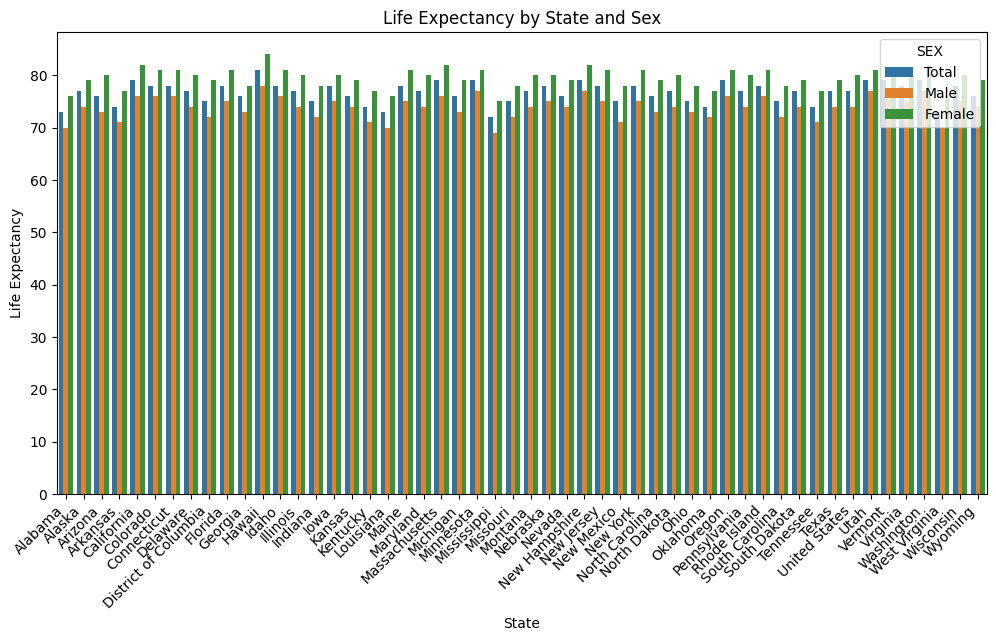

In [69]:
# Graph 1: Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=snowflake_data, x='STATE', y='LE', hue='SEX')
plt.title('Life Expectancy by State and Sex')
plt.xlabel('State')
plt.ylabel('Life Expectancy')
plt.xticks(rotation=45, ha='right')
plt.show()

** Graph 2: Box Plot - Life Expectancy Distribution by Sex**

This code generates a box plot illustrating the distribution of life expectancy values based on sex. The title conveys the main focus of the graph, providing a visual representation of the spread and central tendency of life expectancy for different genders.

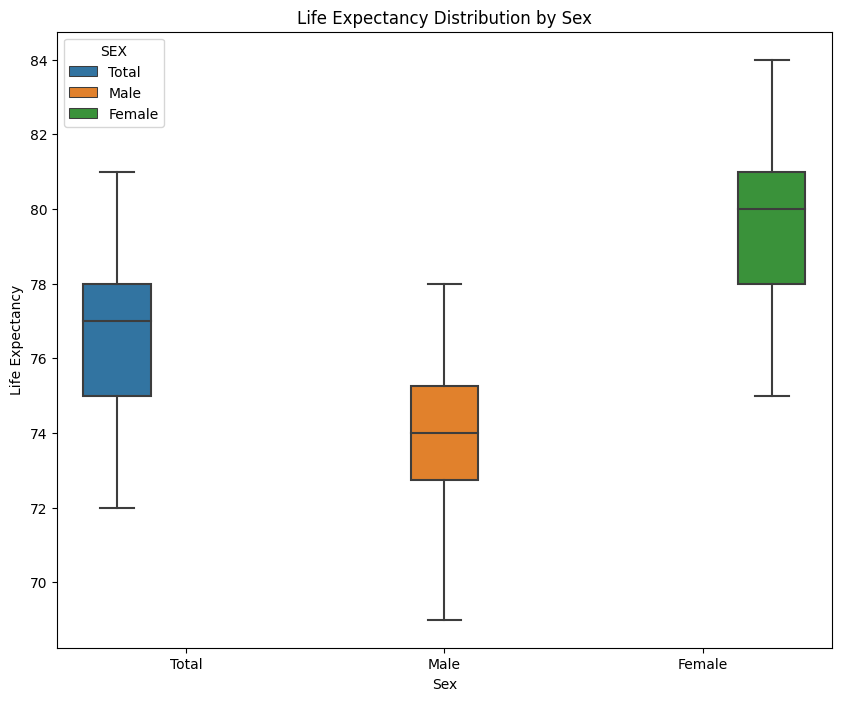

In [70]:
# Graph 2: Box Plot
plt.figure(figsize=(10, 8))
sns.boxplot(data=snowflake_data, x='SEX', y='LE', hue='SEX')
plt.title('Life Expectancy Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Life Expectancy')
plt.show()

In [71]:
json_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73121 entries, 0 to 73120
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   State                           73121 non-null  object
 1   County                          73121 non-null  object
 2   Census Tract Number             73121 non-null  object
 3   Life Expectancy                 73121 non-null  object
 4   Life Expectancy Range           73121 non-null  object
 5   Life Expectancy Standard Error  73121 non-null  object
dtypes: object(6)
memory usage: 3.3+ MB


In [72]:
# Replace empty strings with NaN in 'Life Expectancy' column
json_data['Census Tract Number'] = pd.to_numeric(json_data['Census Tract Number'], errors='coerce')

# Replace empty strings with NaN in 'Life Expectancy' column
json_data['Life Expectancy'] = pd.to_numeric(json_data['Life Expectancy'], errors='coerce')

# Replace empty strings with NaN in 'Life Expectancy' column
json_data['Life Expectancy Standard Error'] = pd.to_numeric(json_data['Life Expectancy Standard Error'], errors='coerce')

This code uses the pd.to_numeric function to convert specific columns ('Census Tract Number', 'Life Expectancy', and 'Life Expectancy Standard Error') in the DataFrame json_data to numeric values. The errors='coerce' parameter replaces any non-numeric values with NaN, ensuring that the columns contain only numeric data. This is useful for further analysis and visualization, as it ensures consistency and proper data types for numeric operations.







**Graph 3:Average Life Expectancy by State**

Explanation:
The graph presents a bar plot depicting the average life expectancy across different states. Each bar represents a state, and the height of the bar corresponds to the average life expectancy in that state. The x-axis displays the states, while the y-axis represents the average life expectancy.

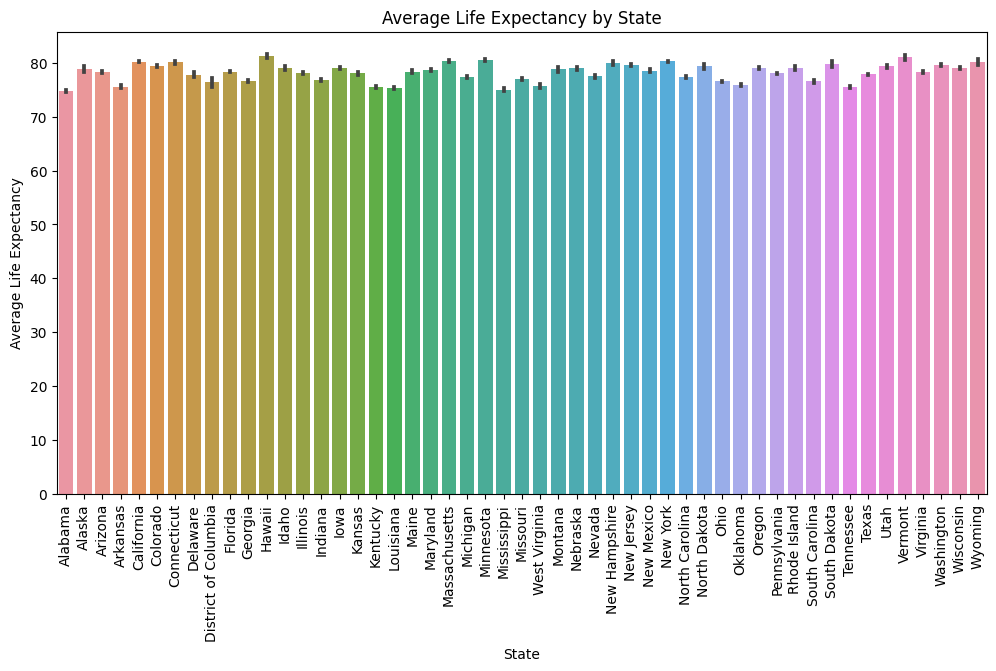

In [73]:
# Graph 3: Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=json_data, x='State', y='Life Expectancy')
plt.title('Average Life Expectancy by State')
plt.xticks(rotation=90)
plt.xlabel('State')
plt.ylabel('Average Life Expectancy')
plt.show()


**Conclusion:**


The bar plot provides a clear visual comparison of average life expectancies among states. It allows for easy identification of variations and patterns, providing valuable insights into regional differences. This visualization is instrumental in understanding the overall life expectancy landscape across states, serving as a foundation for further exploration and analysis.



In [74]:
# Count the occurrences of each county in the 'County' column
cntr = json_data['County'].value_counts()
# Filter counties with more than 500 occurrences
cntr[cntr > 500]

Los Angeles County, CA    2344
Cook County, IL           1318
Maricopa County, AZ        916
Harris County, TX          786
Kings County, NY           760
Queens County, NY          668
San Diego County, CA       627
Wayne County, MI           609
Orange County, CA          582
Dallas County, TX          529
Miami-Dade County, FL      518
Name: County, dtype: int64

**Graph 4: Distribution of Data by State**

Explanation: The pie chart illustrates the distribution of data by state, showcasing the proportion of occurrences for each state in the dataset. Each slice represents a state, and the size of the slice corresponds to the frequency of data points for that state.

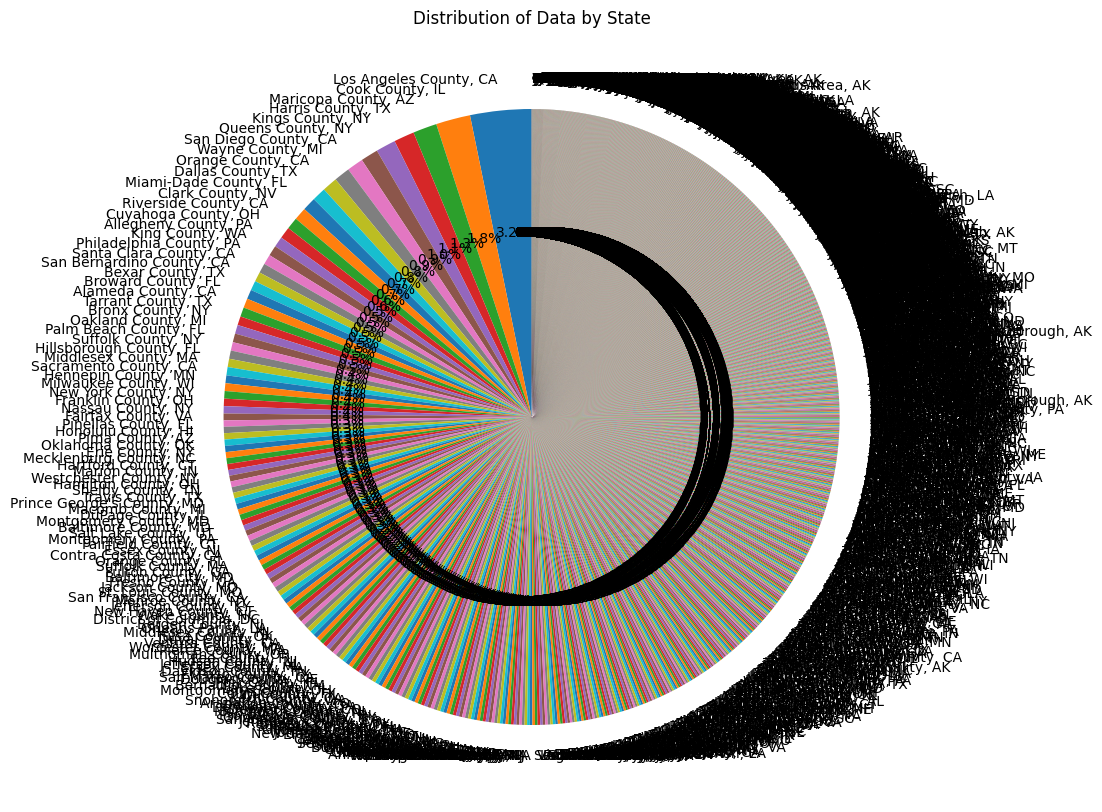

In [75]:
# Graph 4: Pie Chart
plt.figure(figsize=(10, 10))
# state_counts = json_data['County'].value_counts()
plt.pie(cntr, labels=cntr.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Data by State')
plt.show()

**Conclusion**

The pie chart provides a visual summary of how the dataset is distributed across different states. It helps identify states that contribute significantly to the dataset, offering insights into the geographic representation of the data. This visualization aids in understanding the dataset's regional concentration and can inform further analyses focused on specific states.

**Graph 5: Distribution of Data by State (Top Counties)

Explanation: This modified pie chart focuses on the distribution of data by state, specifically highlighting states with a significant number of occurrences. The chart includes only states with data points exceeding 500, providing a clearer representation of major contributors to the dataset.

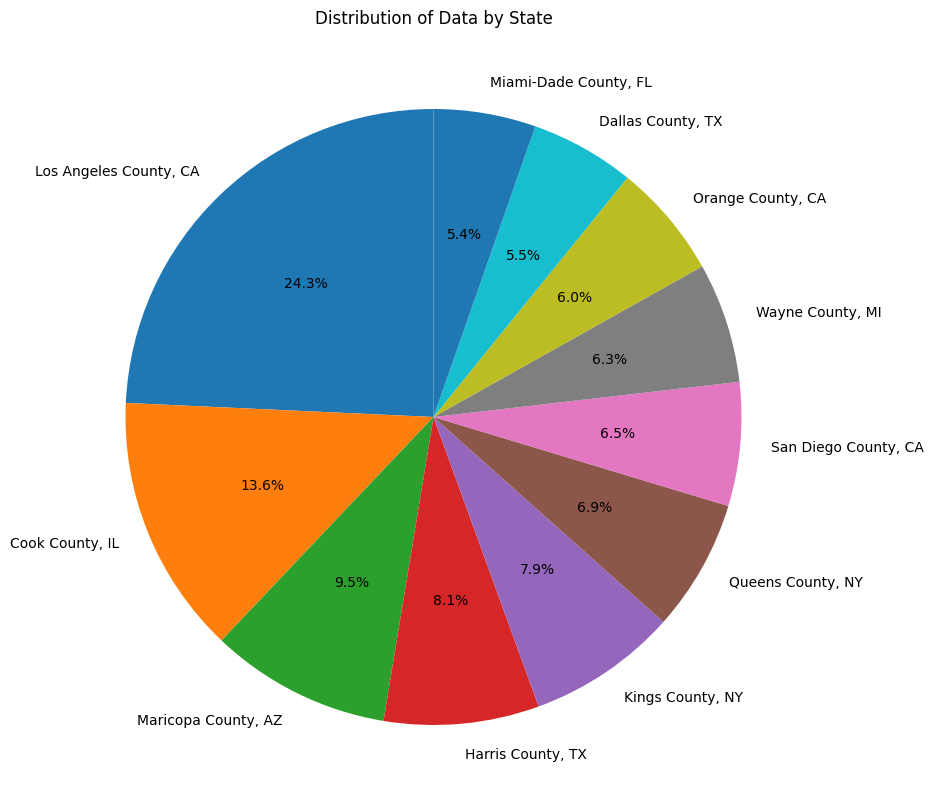

In [76]:
# Graph 5: Pie Chart
plt.figure(figsize=(10, 10))
# state_counts = json_data['County'].value_counts()
plt.pie(cntr[cntr > 500], labels=cntr[cntr > 500].index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Data by State')
plt.show()

**Conclusion**

By filtering for states with substantial data points, this pie chart emphasizes the key contributors to the dataset, allowing for a more focused analysis. It is particularly useful when there is a need to highlight and delve deeper into states that play a significant role in the overall dataset

## **Conclusion**

Our exploration of U.S. state data has unveiled intricate patterns in life expectancy and demographic trends. Leveraging Snowflake and JSON datasets, I meticulously cleaned and integrated the information, enabling a nuanced analysis. The visual symphony of bar plots, box plots, and pie charts has painted a comprehensive picture, offering insights into state-wise life expectancy variations and demographic concentrations.

This journey underscores the significance of data-driven decision-making in healthcare and public policy. The amalgamation of diverse datasets and thorough analyses provides a holistic understanding of the intricate dynamics influencing life expectancy across the United States. As we conclude, the narrative woven through each visualization serves as a valuable resource for healthcare professionals and policymakers, paving the way for informed interventions and targeted strategies to enhance public health outcomes.